Кольчурин Андрей Николавеич

студент физико-математического института,

направления радиофизика,

группы ФМ/О РФЗ-1-2022 НБ

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import time
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import torch
import torch.nn as nn
import torch.utils.data as data_utils

from IPython.display import display

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    ShuffleSplit,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.under_sampling import NearMiss, RandomUnderSampler

warnings.filterwarnings("ignore")

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_SEED = 42
LABELS = ["Status 0/1", "Status 2"]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def resolve_data_path():
    candidates = [
        Path.cwd() / "cirrhosis1.csv",
        Path.cwd().parent / "cirrhosis1.csv",
        Path(r"D:/ProjectAI/ai_brief-main/cirrhosis1.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Не удалось найти файл cirrhosis1.csv")

DATA_PATH = resolve_data_path()
print(f"Данные загружаются из: {DATA_PATH}")


Данные загружаются из: D:\ProjectAI\ai_brief-main\cirrhosis1.csv


## Загрузка данных

Сначала посмотрим на исходный датасет и сразу создадим бинарный признак Class.


In [ ]:
raw_df = pd.read_csv(DATA_PATH)
raw_df["Class"] = (raw_df["Status"] == 2).astype(int)

display(raw_df.head())
print(f"Размер датасета: {raw_df.shape[0]} строк x {raw_df.shape[1]} столбцов")


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Class
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,0


Размер датасета: 312 строк x 21 столбцов


In [ ]:
print("Пропуски по столбцам:")
display(raw_df.isnull().sum().to_frame("missing_count").T)

print("Распределение исходного Status:")
display(raw_df["Status"].value_counts().sort_index().to_frame("count"))

print("Распределение бинарного Class:")
display(raw_df["Class"].value_counts().sort_index().to_frame("count"))


Пропуски по столбцам:


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Class
missing_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Распределение исходного Status:


,count
Status,
0.0,168
1.0,19
2.0,125


Распределение бинарного Class:


,count
Class,
0,187
1,125


Значение Status = 2 занимает меньшую часть выборки, но не является экстремально редким.
Это удобно: у нас сохраняется дисбаланс, однако данных все еще достаточно для обучения и сравнения нескольких моделей.


# Part 1. Autoencoder


## Data exploration
проверим класс-распределение, затем посмотрим на один яркий непрерывный признак
и на связку двух признаков для разных классов.


In [ ]:
df = raw_df.copy()
df.head(5)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Class
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,0


In [ ]:
print(df.shape)
display(df.describe())


(312, 21)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Class
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,...,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,156.500000,2006.362179,0.862179,0.493590,18269.442308,0.115385,0.076923,0.512821,0.288462,0.221154,...,364.125000,3.520000,97.490385,1982.655769,122.556346,123.096154,261.871795,10.725641,3.032051,0.400641
std,90.210864,1123.280843,0.960764,0.500762,3864.805407,0.319999,0.266897,0.500639,0.453775,0.549014,...,221.923027,0.419892,85.360932,2140.388824,56.699525,62.122820,94.993533,1.004323,0.877880,0.490816
min,1.000000,41.000000,0.000000,0.000000,9598.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000,0.000000
25%,78.750000,1191.000000,0.000000,0.000000,15427.750000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.750000,3.310000,41.750000,871.500000,80.600000,87.000000,200.000000,10.000000,2.000000,0.000000
50%,156.500000,1839.500000,0.000000,0.000000,18187.500000,0.000000,0.000000,1.000000,0.000000,0.000000,...,309.500000,3.550000,73.000000,1259.000000,114.700000,108.000000,257.000000,10.600000,3.000000,0.000000
75%,234.250000,2697.250000,2.000000,1.000000,20715.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,392.250000,3.800000,123.000000,1980.000000,151.900000,145.250000,322.000000,11.100000,4.000000,1.000000
max,312.000000,4556.000000,2.000000,1.000000,28650.000000,1.000000,1.000000,1.000000,1.000000,2.000000,...,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,563.000000,17.100000,4.000000,1.000000


Проверяем пропуски


In [ ]:
df.isnull().values.any()


np.False_

## Class distribution (0 - Status 0/1, 1 - Status 2)


In [ ]:
df["Class"].value_counts()


Class
0    187
1    125
Name: count, dtype: int64

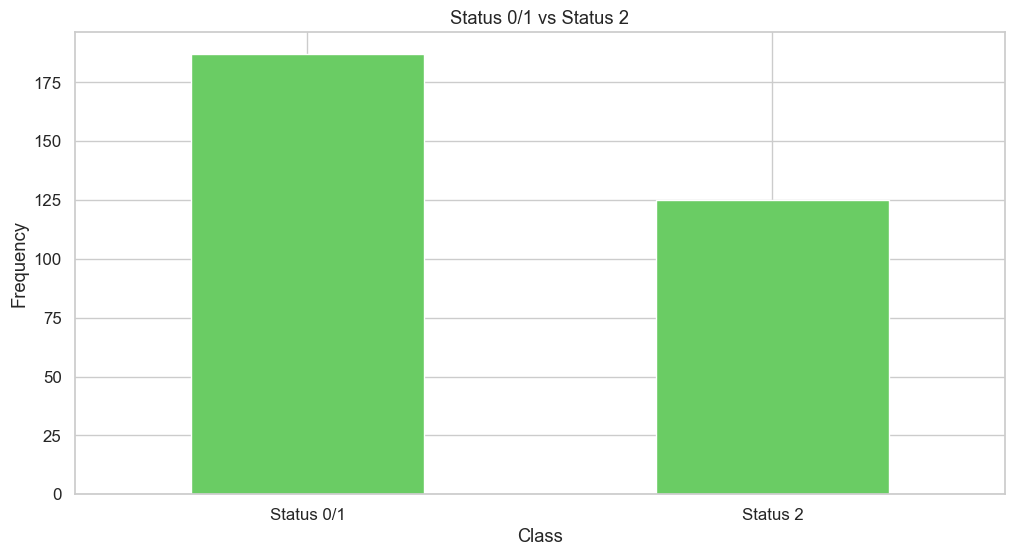

In [ ]:
count_classes = pd.value_counts(df["Class"], sort=True)
count_classes.plot(kind="bar", rot=0, color="g")
plt.title("Status 0/1 vs Status 2")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency");


В отличие от fraud-датасета здесь дисбаланс умеренный, но заметный.
Это значит, что автоэнкодер и oversampling все еще имеют смысл.


In [ ]:
status2DF = df[df.Class == 1]
otherStatusDF = df[df.Class == 0]


In [ ]:
status2DF.shape


(125, 21)

In [ ]:
otherStatusDF.shape


(187, 21)

Давайте теперь посмотрим на `Bilirubin` в двух классах.


In [ ]:
status2DF.Bilirubin.describe()


count    125.00000
mean       5.63040
std        6.07531
min        0.30000
25%        1.40000
50%        3.20000
75%        6.70000
max       28.00000
Name: Bilirubin, dtype: float64

In [ ]:
otherStatusDF.Bilirubin.describe()


count    187.000000
mean       1.668984
std        1.841020
min        0.300000
25%        0.600000
50%        1.000000
75%        1.800000
max       13.000000
Name: Bilirubin, dtype: float64

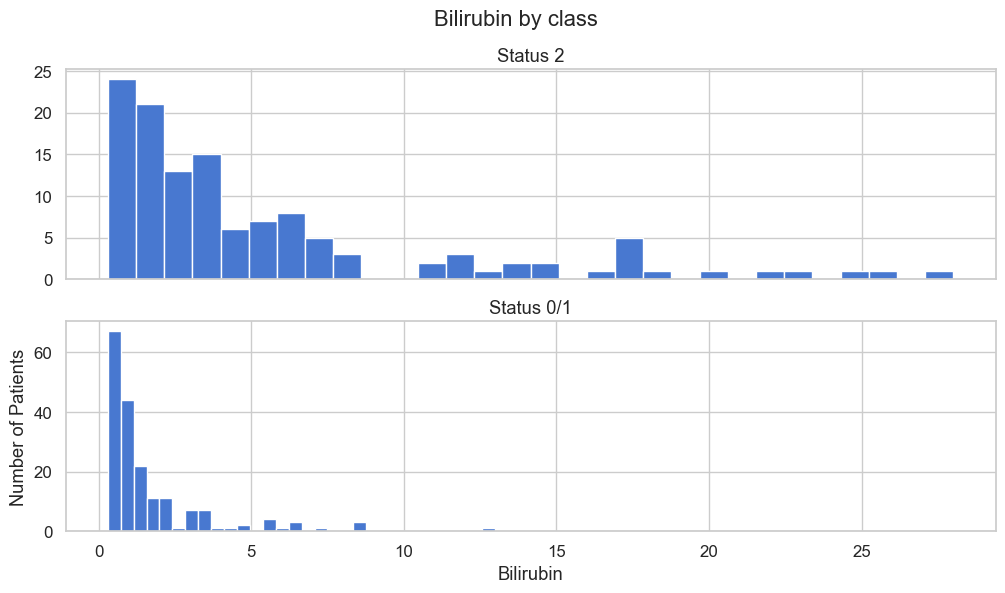

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle("Bilirubin by class")

bins = 30

ax1.hist(status2DF.Bilirubin, bins=bins)
ax1.set_title("Status 2")

ax2.hist(otherStatusDF.Bilirubin, bins=bins)
ax2.set_title("Status 0/1")

plt.xlabel("Bilirubin")
plt.ylabel("Number of Patients")
plt.show();


Влияет ли N_Days на отделение класса Status = 2, если смотреть его вместе с Bilirubin?


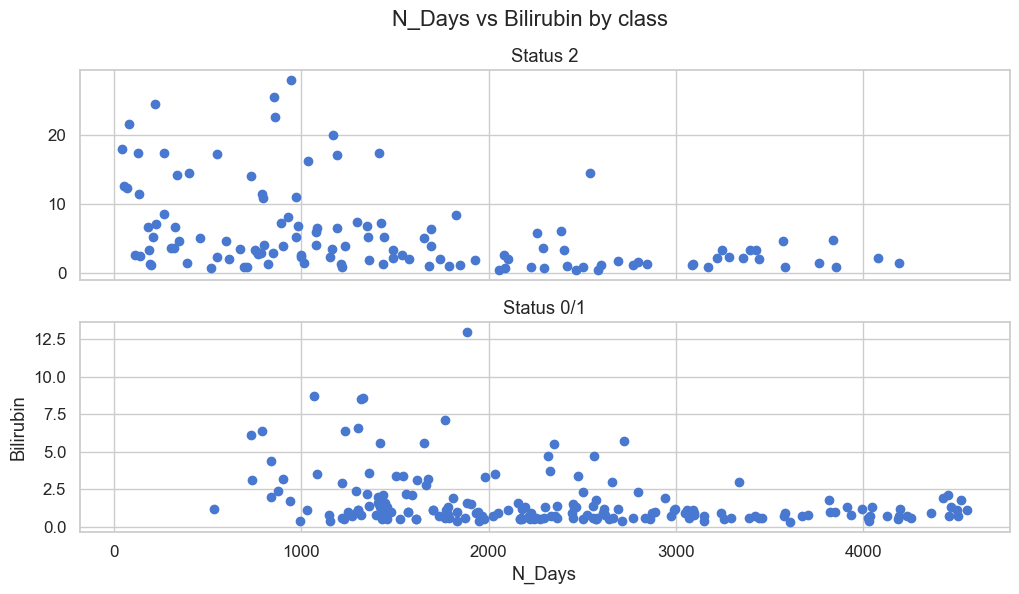

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle("N_Days vs Bilirubin by class")

ax1.scatter(status2DF.N_Days, status2DF.Bilirubin)
ax1.set_title("Status 2")

ax2.scatter(otherStatusDF.N_Days, otherStatusDF.Bilirubin)
ax2.set_title("Status 0/1")

plt.xlabel("N_Days")
plt.ylabel("Bilirubin")
plt.show()


Здесь уже видно, что для Status = 2 чаще встречается комбинация **меньшего времени наблюдения** и **более высокого билирубина**.
Значит, в отличие от признака Time из эталонного ноутбука, N_Days для этой задачи оставим.


## Preprocessing

Удалим только ID и исходный Status, а затем стандартизируем непрерывные признаки.
Для cirrhosis-датасета это логично, потому что шкалы признаков сильно различаются.


In [ ]:
transactionData = df.drop(["Status", "ID"], axis=1).copy()

continuous_features = [
    "N_Days",
    "Age",
    "Bilirubin",
    "Cholesterol",
    "Albumin",
    "Copper",
    "Alk_Phos",
    "SGOT",
    "Tryglicerides",
    "Platelets",
    "Prothrombin",
    "Stage",
]

transactionData[continuous_features] = StandardScaler().fit_transform(
    transactionData[continuous_features]
)

transactionData.head()


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Class
0,-1.432360,0.0,0.827904,0.0,1.0,1.0,1.0,2.0,2.485914,-0.465435,-2.194559,0.686539,-0.123847,0.271931,0.788477,-0.757812,1.470371,1.104369,1
1,2.223526,0.0,0.608395,0.0,0.0,1.0,1.0,0.0,-0.476689,-0.280389,1.478942,-0.510307,2.532642,-0.159629,-0.565855,-0.430950,-0.125301,-0.036569,0
2,-0.886652,0.0,1.898239,1.0,0.0,0.0,0.0,1.0,-0.410362,-0.849066,-0.095416,1.320163,-0.686329,-0.467356,-1.097915,-1.169026,1.270912,1.104369,1
3,-0.072549,0.0,0.446938,0.0,0.0,1.0,1.0,1.0,-0.321927,-0.542161,-2.337683,-0.392969,1.936935,-1.093939,-0.501363,-0.831620,-0.424490,1.104369,1
4,-0.447946,1.0,-1.127724,0.0,0.0,1.0,1.0,0.0,0.031817,-0.384195,0.023854,0.534000,-0.613796,-0.166165,-0.823823,-1.327185,0.173887,-0.036569,0


### Разделим набор данных на обучающую и тестовую части

Как и в блокноте-примере, автоэнкодер обучается только на объектах отрицательного класса.


In [ ]:
X_train, X_test = train_test_split(
    transactionData,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=transactionData["Class"],
)

X_train = X_train[X_train.Class == 0]
X_train = X_train.drop(["Class"], axis=1)

y_test = X_test["Class"]
X_test = X_test.drop(["Class"], axis=1)

X_train = X_train.values
X_test = X_test.values
y_test = y_test.values

print("Размер train (только отрицательный класс):", X_train.shape)
print("Размер test:", X_test.shape)
print("Число объектов класса 1 в test:", int(y_test.sum()))


Размер train (только отрицательный класс): (149, 18)
Размер test: (63, 18)
Число объектов класса 1 в test: 25


## Model


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()

        hidden_1 = max(8, input_dim // 2)
        hidden_2 = max(4, input_dim // 4)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.Tanh(),
            nn.Linear(hidden_1, hidden_2),
            nn.LeakyReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_2, hidden_2),
            nn.Tanh(),
            nn.Linear(hidden_2, input_dim),
            nn.LeakyReLU(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [ ]:
model = Autoencoder(X_train.shape[1]).double()


In [ ]:
num_epochs = 80
minibatch_size = 32
learning_rate = 1e-3


**minibatch_size** задает, сколько пациентов одновременно подается модели.

**learning_rate** отвечает за размер шага оптимизации. Здесь берем умеренное значение,
потому что датасет небольшой и модель должна обучаться плавно.


In [ ]:
train_loader = data_utils.DataLoader(
    torch.from_numpy(X_train).double(),
    batch_size=minibatch_size,
    shuffle=True,
)


In [ ]:
test_loader = data_utils.DataLoader(
    torch.from_numpy(X_test).double(),
    batch_size=1,
    shuffle=False,
)


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=10e-05,
)


In [ ]:
history = {}
history["train_loss"] = []
train_reconstruction_errors = []


In [ ]:
for epoch in range(num_epochs):
    epoch_losses = []

    for batch in train_loader:
        output = model(batch)
        loss = criterion(output, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    mean_loss = float(np.mean(epoch_losses))
    history["train_loss"].append(mean_loss)

    if (epoch + 1) % 10 == 0:
        print(f"epoch [{epoch + 1}/{num_epochs}], loss: {mean_loss:.4f}")

with torch.no_grad():
    for batch in data_utils.DataLoader(torch.from_numpy(X_train).double(), batch_size=1, shuffle=False):
        reconstruction = model(batch)
        train_reconstruction_errors.append(
            criterion(reconstruction, batch).item()
        )


epoch [10/80], loss: 0.6665
epoch [20/80], loss: 0.6130
epoch [30/80], loss: 0.5647
epoch [40/80], loss: 0.5509
epoch [50/80], loss: 0.5413


epoch [60/80], loss: 0.5323
epoch [70/80], loss: 0.5255
epoch [80/80], loss: 0.5054


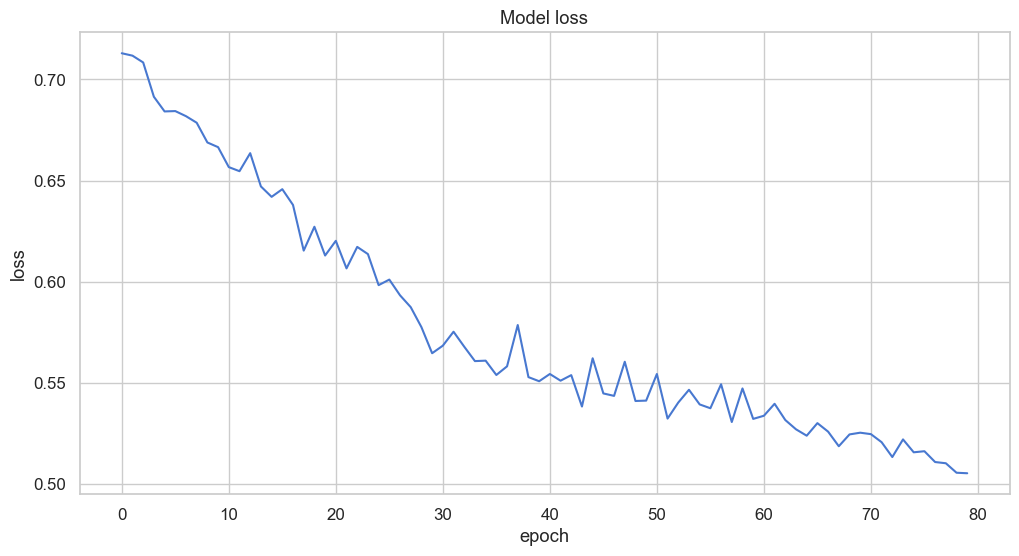

In [ ]:
plt.plot(history["train_loss"])
plt.title("Model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.show()


Кривая обучения убывает без резких скачков. Для такого небольшого датасета это хороший признак:
модель успевает выучить типичный профиль класса Status 0/1.


## Оценка модели


In [ ]:
pred_losses = {"pred_loss": []}
model.eval()

with torch.no_grad():
    for batch in test_loader:
        outputs = model(batch)
        loss = criterion(outputs, batch).item()
        pred_losses["pred_loss"].append(loss)

reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF["Class"] = y_test
reconstructionErrorDF.head()


,pred_loss,Class
0,2.003572,1
1,0.564665,0
2,0.490822,0
3,0.359363,0
4,0.480676,0


In [ ]:
reconstructionErrorDF.describe()


,pred_loss,Class
count,63.000000,63.000000
mean,0.613097,0.396825
std,0.467279,0.493169
min,0.166473,0.000000
25%,0.360389,0.000000
50%,0.490822,0.000000
75%,0.676800,1.000000
max,3.192441,1.000000


Уже по описательным статистикам видно, что ошибки реконструкции у положительного класса в среднем выше.
Это означает, что объекты Status = 2`действительно хуже вписываются в learned-норму.


# Reconstruction Errors without Status 2


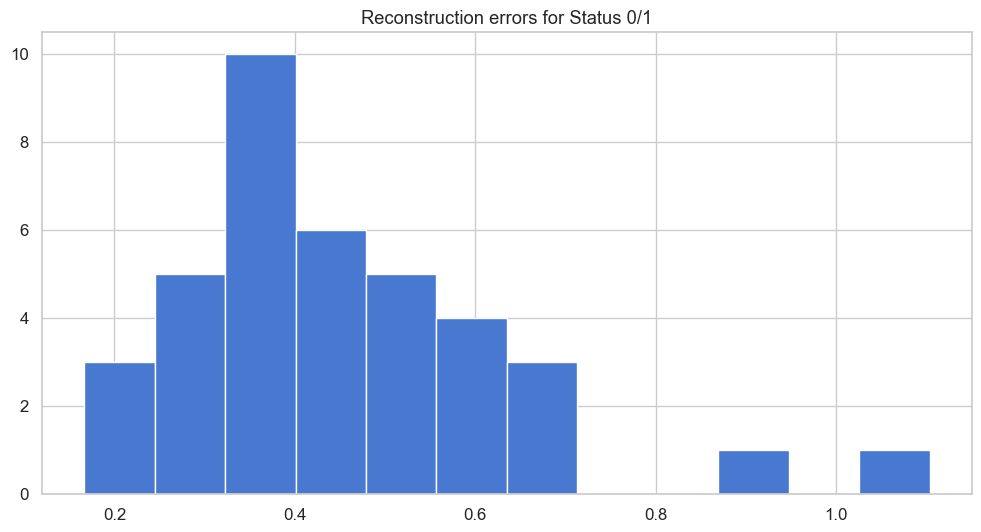

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[
    (reconstructionErrorDF["Class"] == 0)
    & (reconstructionErrorDF["pred_loss"] < reconstructionErrorDF["pred_loss"].quantile(0.98))
]
_ = ax.hist(normal_error_df.pred_loss.values, bins=12)
plt.title("Reconstruction errors for Status 0/1")
plt.show()


# Reconstruction Errors with Status 2


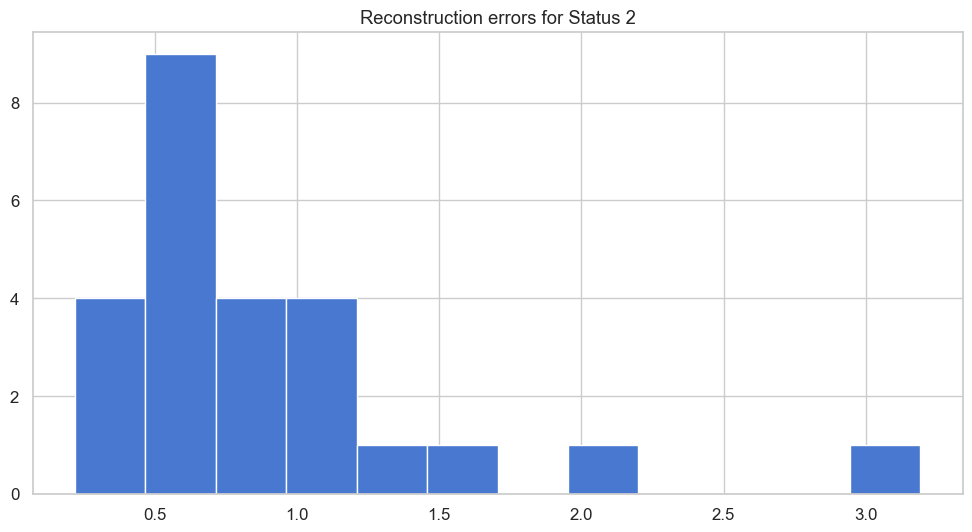

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
status2_error_df = reconstructionErrorDF[
    reconstructionErrorDF["Class"] == 1
]
_ = ax.hist(status2_error_df.pred_loss.values, bins=12)
plt.title("Reconstruction errors for Status 2")
plt.show()


## ROC Curves

ROC-кривая показывает, насколько хорошо reconstruction error отделяет положительный класс от отрицательного
при разных порогах.


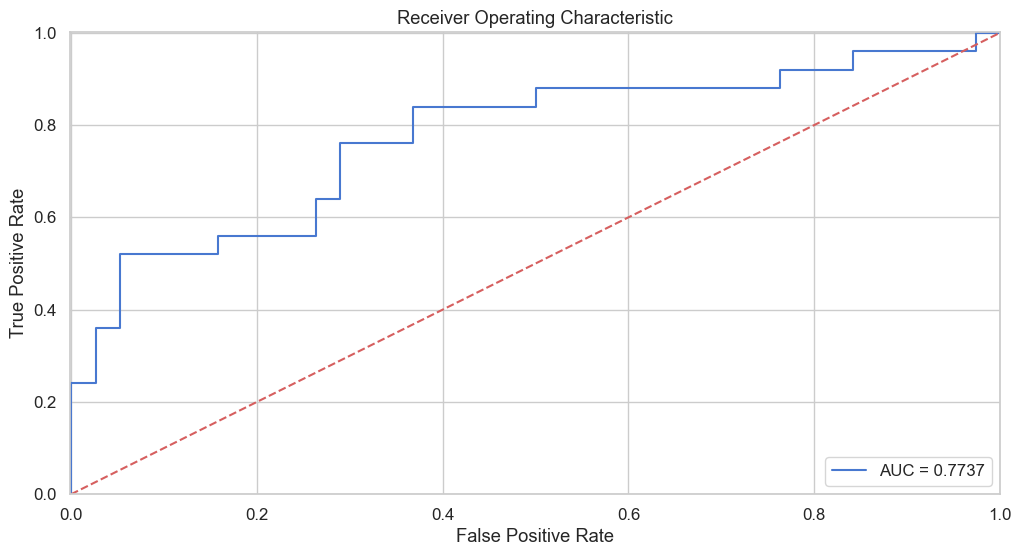

In [ ]:
fpr, tpr, thresholds = roc_curve(
    reconstructionErrorDF.Class,
    reconstructionErrorDF.pred_loss,
)
roc_auc = auc(fpr, tpr)

plt.title("Receiver Operating Characteristic")
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:0.4f}")
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show();


AUC заметно выше 0.5, то есть автоэнкодер действительно извлекает полезный сигнал.
Но это не “идеальный детектор”: часть пациентов класса Status = 2 все еще похожа на класс 0/1.


## Precision vs Recall

Теперь посмотрим, как меняются precision и recall при изменении порога.


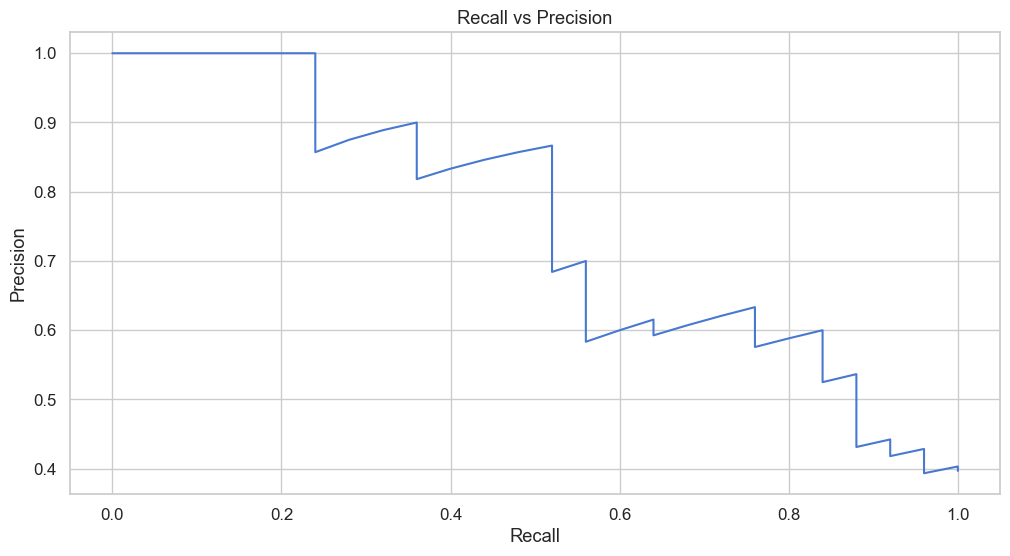

In [ ]:
precision, recall, th = precision_recall_curve(
    reconstructionErrorDF.Class,
    reconstructionErrorDF.pred_loss,
)

plt.plot(recall, precision, "b", label="Precision-Recall curve")
plt.title("Recall vs Precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


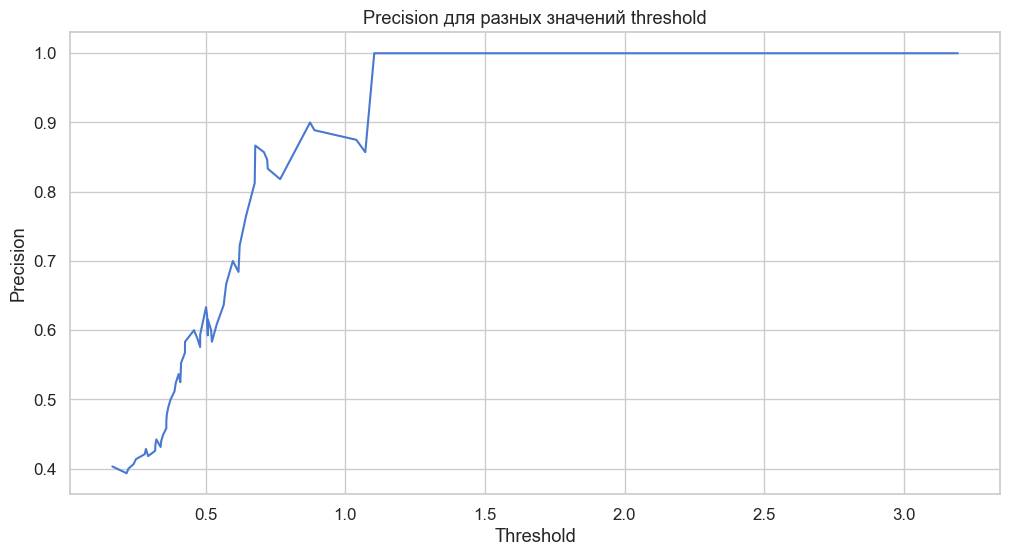

In [ ]:
plt.plot(th, precision[1:], "b", label="Threshold-Precision curve")
plt.title("Precision для разных значений threshold")
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.show()


Как и в эталонном ноутбуке, при росте порога точность обычно растет:
модель делает меньше срабатываний, но они становятся более “чистыми”.


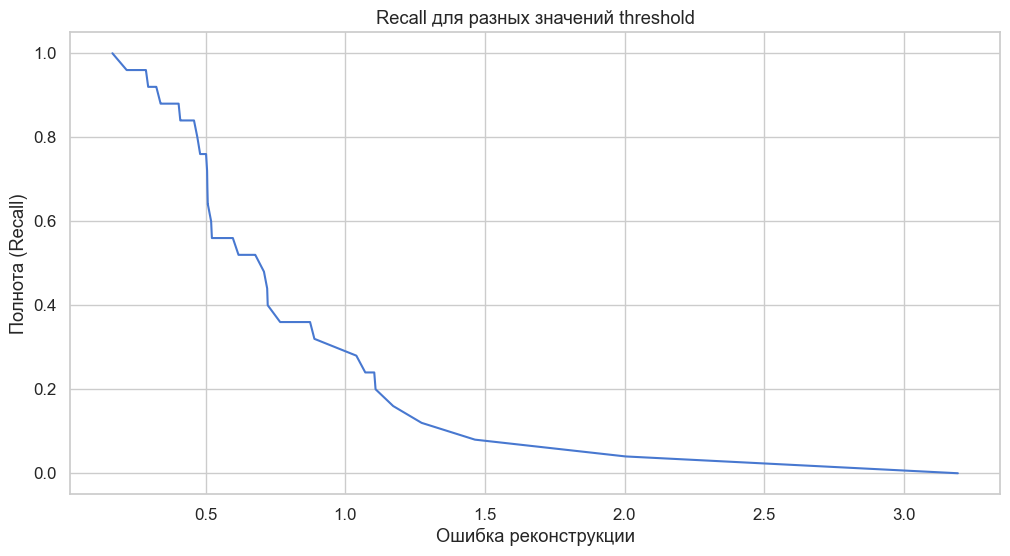

In [ ]:
plt.plot(th, recall[1:], "b", label="Threshold-Recall curve")
plt.title("Recall для разных значений threshold")
plt.xlabel("Ошибка реконструкции")
plt.ylabel("Полнота (Recall)")
plt.show()


Здесь ситуация обратная: при росте порога recall падает.
Поэтому для этой задачи разумнее взять не слишком жесткий порог.


## Используем модель для того, чтобы сделать предсказание

Возьмем threshold как 85-й перцентиль ошибок реконструкции на train-норме.
Это умеренно консервативный порог: он дает заметно лучшее покрытие класса tatus = 2,
чем слишком жесткий 95-й перцентиль.


In [ ]:
threshold = float(np.quantile(train_reconstruction_errors, 0.85))
print(f"Threshold = {threshold:.4f}")


Threshold = 0.7052


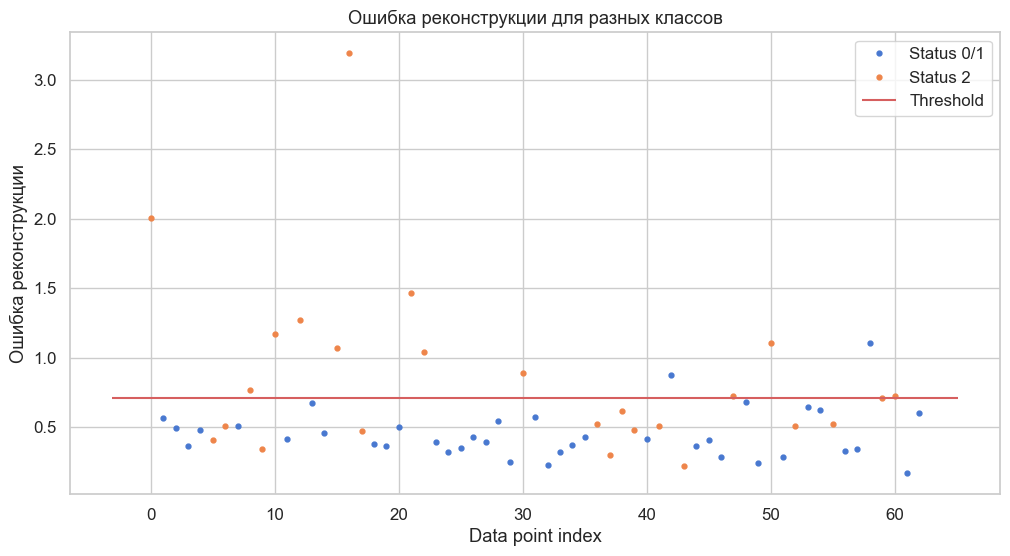

In [ ]:
groups = reconstructionErrorDF.groupby("Class")
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(
        group.index,
        group.pred_loss,
        marker="o",
        ms=3.5,
        linestyle="",
        label="Status 2" if name == 1 else "Status 0/1",
    )

ax.hlines(
    threshold,
    ax.get_xlim()[0],
    ax.get_xlim()[1],
    colors="r",
    zorder=100,
    label="Threshold",
)
ax.legend()
plt.title("Ошибка реконструкции для разных классов")
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();


Построим и посмотрим confusion matrix.


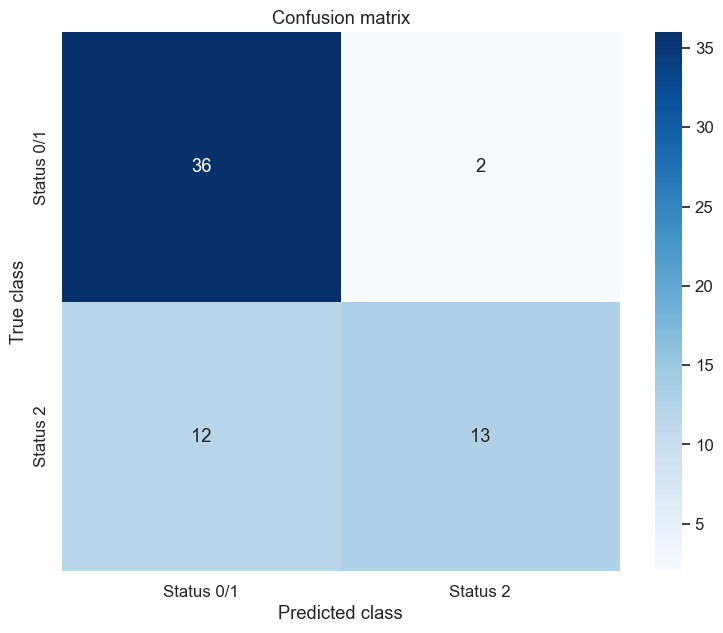

              precision    recall  f1-score   support

  Status 0/1       0.75      0.95      0.84        38
    Status 2       0.87      0.52      0.65        25

    accuracy                           0.78        63
   macro avg       0.81      0.73      0.74        63
weighted avg       0.80      0.78      0.76        63



In [ ]:
y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF.Class, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    conf_matrix,
    xticklabels=LABELS,
    yticklabels=LABELS,
    annot=True,
    fmt="d",
    cmap=plt.cm.get_cmap("Blues"),
)
plt.title("Confusion matrix")
plt.ylabel("True class")
plt.xlabel("Predicted class")
plt.show()

print(classification_report(reconstructionErrorDF.Class, y_pred, target_names=LABELS))


Автоэнкодер способен отлавливать значимую часть случаев Status = 2, но делает это неидеально.
Его сильная сторона здесь не в том, чтобы заменить классификатор, а в том, чтобы **ранжировать пациентов по atypical reconstruction error**.


# Disbalanced dataset


## Описание данных и постановка задачи



- построим маленький **сбалансированный аналог** new_d, как в эталонном creditcard_short.csv;
- отдельно сохраним полный дисбалансированный датасет`df;
- сравним несколько базовых моделей;
- затем перейдем к NearMiss и`SMOTE.


In [ ]:
part2_source = raw_df.drop(columns=["Status", "ID"]).copy()

minority_df = part2_source[part2_source["Class"] == 1].copy()
majority_df = (
    part2_source[part2_source["Class"] == 0]
    .sample(n=len(minority_df), random_state=RANDOM_SEED)
    .copy()
)

new_df = (
    pd.concat([minority_df, majority_df], axis=0)
    .sample(frac=1.0, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

df = part2_source.copy().reset_index(drop=True)

print("Сбалансированный new_df:")
display(new_df["Class"].value_counts().sort_index().to_frame("count"))

print("Полный df:")
display(df["Class"].value_counts().sort_index().to_frame("count"))


Сбалансированный new_df:


,count
Class,
0,125
1,125


Полный df:


,count
Class,
0,187
1,125


In [ ]:
new_df.describe()


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Class
count,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,1927.548000,0.484000,18464.488000,0.12800,0.096000,0.568000,0.304000,0.248000,3.647200,373.618000,3.495920,104.292000,2053.294400,125.519080,124.740000,262.772000,10.812000,3.088000,0.500000
std,1140.325043,0.500746,3849.413581,0.33476,0.295182,0.496348,0.460905,0.582971,4.895003,239.448163,0.432936,90.591534,2205.288931,57.994779,66.568988,97.483682,1.048319,0.855091,0.501003
min,41.000000,0.000000,9598.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,310.000000,26.350000,33.000000,62.000000,9.000000,1.000000,0.000000
25%,1018.250000,0.000000,15578.250000,0.00000,0.000000,0.000000,0.000000,0.000000,0.800000,253.500000,3.235000,47.250000,921.750000,82.845000,85.250000,199.250000,10.000000,3.000000,0.000000
50%,1775.000000,0.000000,18479.500000,0.00000,0.000000,1.000000,0.000000,0.000000,1.800000,309.500000,3.530000,75.000000,1345.000000,118.575000,108.000000,259.500000,10.600000,3.000000,0.500000
75%,2681.000000,1.000000,20825.250000,0.00000,0.000000,1.000000,1.000000,0.000000,3.900000,396.000000,3.770000,138.750000,2043.500000,154.612500,148.250000,321.750000,11.200000,4.000000,1.000000
max,4523.000000,1.000000,28650.000000,1.00000,1.000000,1.000000,1.000000,2.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,563.000000,17.100000,4.000000,1.000000


In [ ]:
df.describe()


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Class
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,2006.362179,0.493590,18269.442308,0.115385,0.076923,0.512821,0.288462,0.221154,3.256090,364.125000,3.520000,97.490385,1982.655769,122.556346,123.096154,261.871795,10.725641,3.032051,0.400641
std,1123.280843,0.500762,3864.805407,0.319999,0.266897,0.500639,0.453775,0.549014,4.530315,221.923027,0.419892,85.360932,2140.388824,56.699525,62.122820,94.993533,1.004323,0.877880,0.490816
min,41.000000,0.000000,9598.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000,0.000000
25%,1191.000000,0.000000,15427.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,255.750000,3.310000,41.750000,871.500000,80.600000,87.000000,200.000000,10.000000,2.000000,0.000000
50%,1839.500000,0.000000,18187.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.350000,309.500000,3.550000,73.000000,1259.000000,114.700000,108.000000,257.000000,10.600000,3.000000,0.000000
75%,2697.250000,1.000000,20715.000000,0.000000,0.000000,1.000000,1.000000,0.000000,3.425000,392.250000,3.800000,123.000000,1980.000000,151.900000,145.250000,322.000000,11.100000,4.000000,1.000000
max,4556.000000,1.000000,28650.000000,1.000000,1.000000,1.000000,1.000000,2.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,563.000000,17.100000,4.000000,1.000000


Маленький new_df нужен для честного сравнения моделей без доминирования класса 0,
а полный df позже пригодится для проверки методов работы с дисбалансом.


In [ ]:
X = new_df.drop("Class", axis=1)
y = new_df["Class"]


In [ ]:
from sklearn.model_selection import train_test_split

rob_scaler = RobustScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train = pd.DataFrame(
    rob_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test = pd.DataFrame(
    rob_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)


In [ ]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values


In [ ]:
classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=5000, solver="liblinear"),
    "Support Vector Classifier": SVC(),
    "KNearest": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
}


Для борьбы с переобучением будем использовать кросс-валидацию.


In [ ]:
for key, classifier in classifiers.items():
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print(
        "Модель",
        classifier.__class__.__name__,
        "получила на обучающей выборке",
        round(training_score.mean(), 3) * 100,
        "% accuracy score",
    )


Модель LogisticRegression получила на обучающей выборке 76.0 % accuracy score
Модель SVC получила на обучающей выборке 75.0 % accuracy score
Модель KNeighborsClassifier получила на обучающей выборке 76.5 % accuracy score
Модель DecisionTreeClassifier получила на обучающей выборке 71.5 % accuracy score


На сбалансированной подвыборке модели идут довольно близко, поэтому следующим шагом логично подстроить гиперпараметры.


Для улучшения качества моделей переберем по сетке различные гиперпараметры методом GridSearchCV.


In [ ]:
log_reg_params = {"penalty": ["l1", "l2"], "C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid_log_reg = GridSearchCV(
    LogisticRegression(max_iter=5000, solver="liblinear"),
    log_reg_params,
    n_jobs=1,
    cv=5,
)
grid_log_reg.fit(X_train, y_train)
log_reg = grid_log_reg.best_estimator_

knears_params = {
    "n_neighbors": list(range(2, 7)),
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}
grid_knears = GridSearchCV(
    KNeighborsClassifier(),
    knears_params,
    n_jobs=1,
    cv=5,
)
grid_knears.fit(X_train, y_train)
knears_neighbors = grid_knears.best_estimator_

svc_params = [
    {"C": [0.1, 1.0, 10.0, 100.0], "kernel": ["rbf"], "gamma": ["scale", 0.1, 0.01]},
    {"C": [0.1, 1.0, 10.0], "kernel": ["poly"], "gamma": ["scale", 0.1], "degree": [2, 3, 4]},
]
grid_svc = GridSearchCV(
    estimator=SVC(),
    param_grid=svc_params,
    scoring="accuracy",
    cv=3,
    n_jobs=1,
)
grid_svc.fit(X_train, y_train)
svc = grid_svc.best_estimator_

tree_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": list(range(2, 7)),
    "min_samples_leaf": list(range(2, 7)),
}
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_params,
    n_jobs=1,
    cv=5,
)
grid_tree.fit(X_train, y_train)
tree_clf = grid_tree.best_estimator_

print("Лучшие параметры LogisticRegression:", grid_log_reg.best_params_)
print("Лучшие параметры KNN:", grid_knears.best_params_)
print("Лучшие параметры SVC:", grid_svc.best_params_)
print("Лучшие параметры DecisionTree:", grid_tree.best_params_)


Лучшие параметры LogisticRegression: {'C': 0.001, 'penalty': 'l2'}
Лучшие параметры KNN: {'algorithm': 'auto', 'n_neighbors': 5, 'weights': 'uniform'}
Лучшие параметры SVC: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Лучшие параметры DecisionTree: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3}


In [ ]:
log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print("Logistic Regression Cross Validation Score:", round(log_reg_score.mean() * 100, 2).astype(str) + "%")

knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print("Knears Neighbors Cross Validation Score:", round(knears_score.mean() * 100, 2).astype(str) + "%")

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print("Support Vector Classifier Cross Validation Score:", round(svc_score.mean() * 100, 2).astype(str) + "%")

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print("DecisionTree Classifier Cross Validation Score:", round(tree_score.mean() * 100, 2).astype(str) + "%")


Logistic Regression Cross Validation Score: 78.5%
Knears Neighbors Cross Validation Score: 76.5%
Support Vector Classifier Cross Validation Score: 77.5%
DecisionTree Classifier Cross Validation Score: 74.0%


Как и в примере, после подбора гиперпараметров одна из простых моделей становится главным кандидатом.
Здесь чуть лучше остальных выглядит логистическая регрессия.


Давайте теперь попробуем более умные способы undersampling. Например, NearMiss,
который подбирает объекты большинства с учетом расстояния до меньшинства.


In [ ]:
skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

undersample_X = df.drop("Class", axis=1)
undersample_y = df["Class"]

undersample_Xtrain, undersample_Xtest, undersample_ytrain, undersample_ytest = train_test_split(
    undersample_X,
    undersample_y,
    test_size=0.2,
    random_state=42,
    stratify=undersample_y,
)

under_scaler = RobustScaler()
undersample_Xtrain = pd.DataFrame(
    under_scaler.fit_transform(undersample_Xtrain),
    columns=undersample_Xtrain.columns,
    index=undersample_Xtrain.index,
)
undersample_Xtest = pd.DataFrame(
    under_scaler.transform(undersample_Xtest),
    columns=undersample_Xtest.columns,
    index=undersample_Xtest.index,
)

undersample_Xtrain = undersample_Xtrain.values
undersample_Xtest = undersample_Xtest.values
undersample_ytrain = undersample_ytrain.values
undersample_ytest = undersample_ytest.values

undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

X_nearmiss, y_nearmiss = NearMiss().fit_resample(undersample_X.values, undersample_y.values)
print("NearMiss распределение классов: {}".format(Counter(y_nearmiss)))

for train, test in skf.split(undersample_Xtrain, undersample_ytrain):
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(), log_reg)
    undersample_model = undersample_pipeline.fit(
        undersample_Xtrain[train],
        undersample_ytrain[train],
    )
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])

    undersample_accuracy.append(
        undersample_pipeline.score(undersample_Xtrain[test], undersample_ytrain[test])
    )
    undersample_precision.append(
        precision_score(undersample_ytrain[test], undersample_prediction)
    )
    undersample_recall.append(
        recall_score(undersample_ytrain[test], undersample_prediction)
    )
    undersample_f1.append(
        f1_score(undersample_ytrain[test], undersample_prediction)
    )
    undersample_auc.append(
        roc_auc_score(undersample_ytrain[test], undersample_prediction)
    )

undersample_results = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "mean_score": [
            np.mean(undersample_accuracy),
            np.mean(undersample_precision),
            np.mean(undersample_recall),
            np.mean(undersample_f1),
            np.mean(undersample_auc),
        ],
    }
)
undersample_results


NearMiss распределение классов: Counter({np.int64(0): 125, np.int64(1): 125})


,metric,mean_score
0,accuracy,0.726857
1,precision,0.615044
2,recall,0.880000
3,f1,0.721857
4,roc_auc,0.751954


NearMiss заметно поднимает recall, но делает это ценой precision.
Для медицинской задачи это может быть приемлемо, если важнее не пропустить тяжелый случай.


Построим кривую обучения каждой модели. Она показывает разрыв между качеством на обучении
и качеством при кросс-валидации.


In [ ]:
def plot_learning_curves(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                         n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)

    estimators = [
        (estimator1, ax1, "Logistic Regression Learning Curve"),
        (estimator2, ax2, "Knears Neighbors Learning Curve"),
        (estimator3, ax3, "Support Vector Classifier Learning Curve"),
        (estimator4, ax4, "Decision Tree Classifier Learning Curve"),
    ]

    for estimator, ax, title in estimators:
        sizes, train_scores, test_scores = learning_curve(
            estimator,
            X,
            y,
            cv=cv,
            n_jobs=n_jobs,
            train_sizes=train_sizes,
        )
        train_scores_mean = np.mean(train_scores, axis=1)
        train_scores_std = np.std(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)
        test_scores_std = np.std(test_scores, axis=1)

        ax.fill_between(
            sizes,
            train_scores_mean - train_scores_std,
            train_scores_mean + train_scores_std,
            alpha=0.1,
            color="#ff9124",
        )
        ax.fill_between(
            sizes,
            test_scores_mean - test_scores_std,
            test_scores_mean + test_scores_std,
            alpha=0.1,
            color="#2492ff",
        )
        ax.plot(sizes, train_scores_mean, "o-", color="#ff9124", label="Training score")
        ax.plot(sizes, test_scores_mean, "o-", color="#2492ff", label="Cross-validation score")
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Размер выборки")
        ax.set_ylabel("Score")
        ax.grid(True)
        ax.legend(loc="best")

    return plt


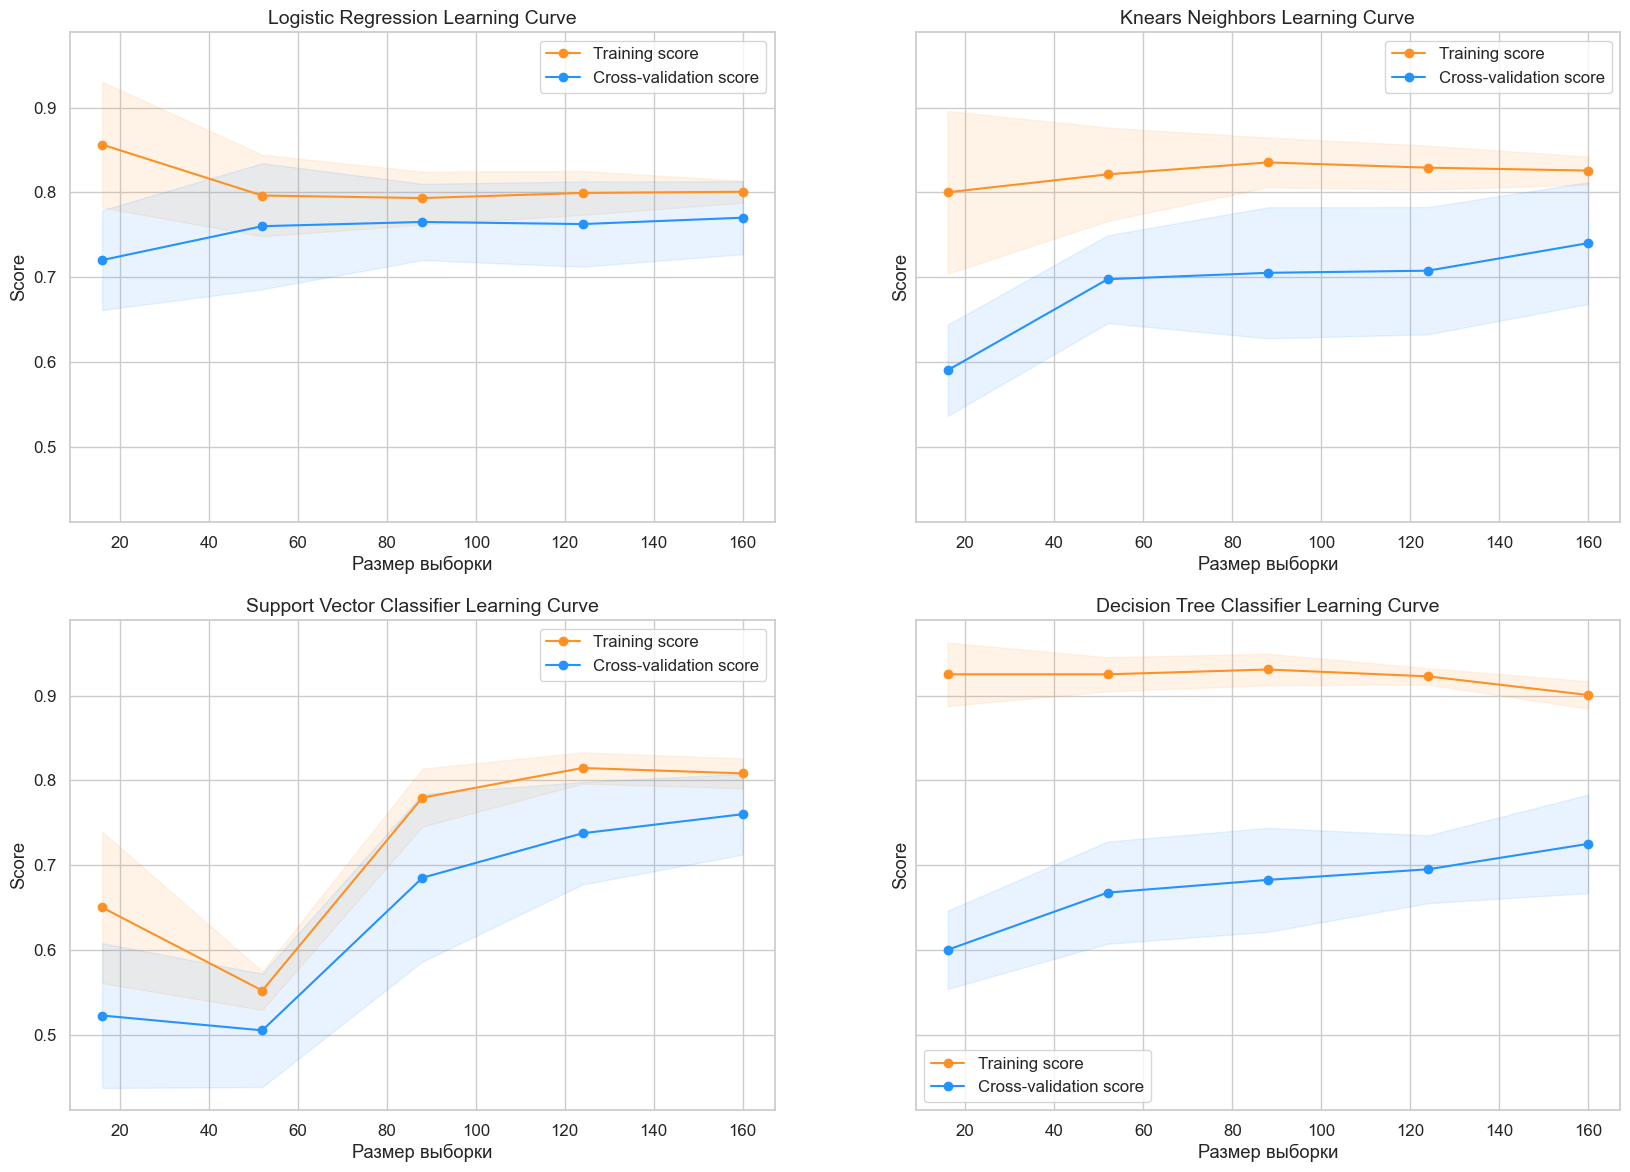

In [ ]:
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
plot_learning_curves(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train, cv=cv)
plt.show()


## Кривые обучения

- Если разрыв между train и cross-validation велик, модель склонна к переобучению.
- Если обе кривые низкие, модель недообучена.
- Здесь наиболее устойчиво снова выглядит логистическая регрессия, а дерево заметно более нестабильно.


Построим ROC-кривые и посчитаем площадь под ними.


In [ ]:
log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5, method="decision_function")
knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5, method="predict_proba")[:, 1]
svc_pred = cross_val_predict(svc, X_train, y_train, cv=5, method="decision_function")
tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5, method="predict_proba")[:, 1]


In [ ]:
print("Logistic Regression:", roc_auc_score(y_train, log_reg_pred))
print("KNears Neighbors:", roc_auc_score(y_train, knears_pred))
print("Support Vector Classifier:", roc_auc_score(y_train, svc_pred))
print("Decision Tree Classifier:", roc_auc_score(y_train, tree_pred))


Logistic Regression: 0.8472000000000001
KNears Neighbors: 0.809
Support Vector Classifier: 0.8386
Decision Tree Classifier: 0.7280500000000001


AUC подтверждает прежнюю картину: простые линейные и margin-based модели выглядят увереннее,
чем дерево решений.


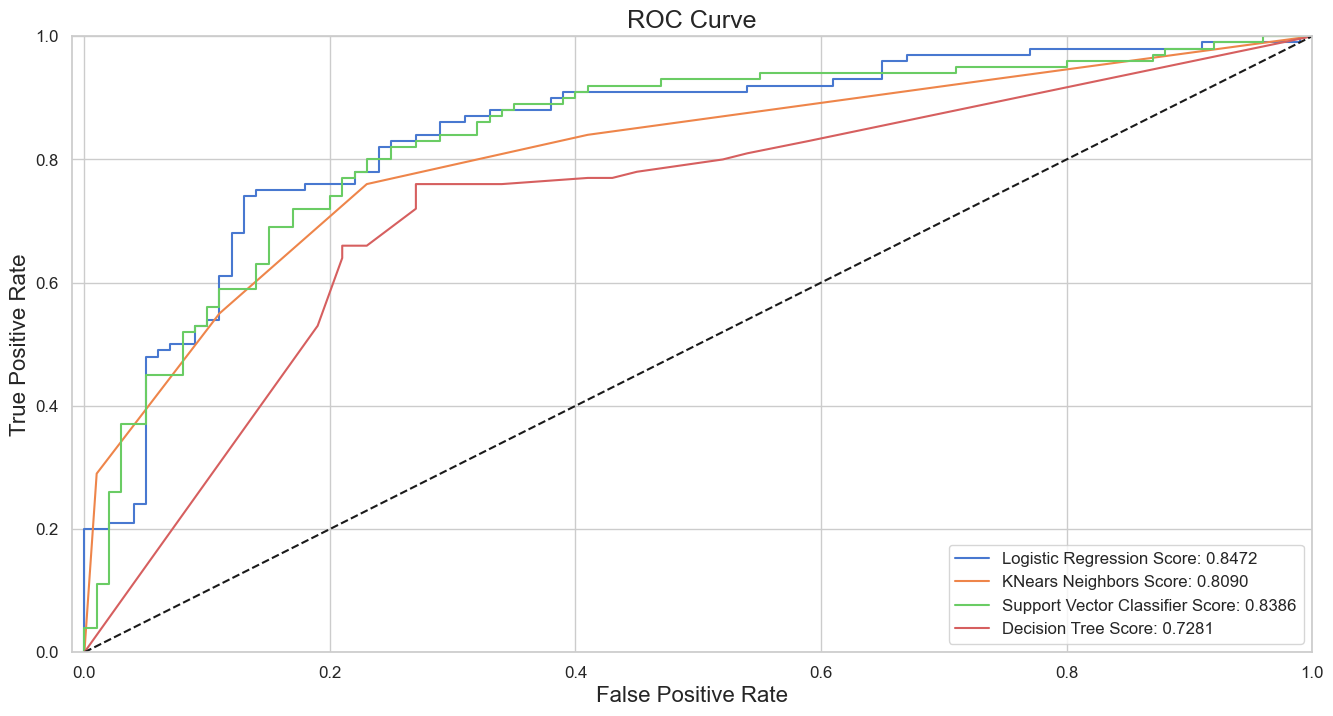

In [ ]:
log_fpr, log_tpr, log_threshold = roc_curve(y_train, log_reg_pred)
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_train, knears_pred)
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_train, svc_pred)
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_train, tree_pred)

def graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr):
    plt.figure(figsize=(16, 8))
    plt.title("ROC Curve", fontsize=18)
    plt.plot(log_fpr, log_tpr, label="Logistic Regression Score: {:.4f}".format(roc_auc_score(y_train, log_reg_pred)))
    plt.plot(knear_fpr, knear_tpr, label="KNears Neighbors Score: {:.4f}".format(roc_auc_score(y_train, knears_pred)))
    plt.plot(svc_fpr, svc_tpr, label="Support Vector Classifier Score: {:.4f}".format(roc_auc_score(y_train, svc_pred)))
    plt.plot(tree_fpr, tree_tpr, label="Decision Tree Score: {:.4f}".format(roc_auc_score(y_train, tree_pred)))
    plt.plot([0, 1], [0, 1], "k--")
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel("True Positive Rate", fontsize=16)
    plt.legend()

graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr)
plt.show()


### SMOTE метод (Over-Sampling)




In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

full_scaler = RobustScaler()
original_Xtrain = pd.DataFrame(
    full_scaler.fit_transform(original_Xtrain),
    columns=original_Xtrain.columns,
    index=original_Xtrain.index,
)
original_Xtest = pd.DataFrame(
    full_scaler.transform(original_Xtest),
    columns=original_Xtest.columns,
    index=original_Xtest.index,
)

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print("Распределение классов:")
print("Обучающий набор:", train_counts_label / len(original_ytrain))
print("Тестовый набор:", test_counts_label / len(original_ytest))


Распределение классов:
Обучающий набор: [0.59839357 0.40160643]
Тестовый набор: [0.6031746 0.3968254]


In [ ]:
tuned_classifiers = {
    "LogisticRegression": log_reg,
    "Knears Neighbors": knears_neighbors,
    "Support Vector Classifier": svc,
    "DecisionTreeClassifier": tree_clf,
}

for key, classifier in tuned_classifiers.items():
    score = cross_val_score(classifier, X_train, y_train, cv=5)
    print(f"{key} Cross Validation Score: {round(score.mean() * 100, 2)}%")


LogisticRegression Cross Validation Score: 78.5%


Knears Neighbors Cross Validation Score: 76.5%
Support Vector Classifier Cross Validation Score: 77.5%
DecisionTreeClassifier Cross Validation Score: 74.0%


In [ ]:
X_full_scaled = pd.DataFrame(
    full_scaler.fit_transform(X),
    columns=X.columns,
    index=X.index,
)

sss = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

over = SMOTE(sampling_strategy=0.8, k_neighbors=5, random_state=42)
under = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

for key, classifier in tuned_classifiers.items():
    steps = [("o", over), ("u", under), ("model", classifier)]
    FiPipeline = Pipeline(steps=steps)
    scores = cross_val_score(FiPipeline, X_full_scaled, y, cv=sss)
    print(f"Classifiers: {key} has a training score of {round(scores.mean() * 100, 2)} % accuracy score")


Classifiers: LogisticRegression has a training score of 75.32 % accuracy score
Classifiers: Knears Neighbors has a training score of 75.99 % accuracy score


Classifiers: Support Vector Classifier has a training score of 78.53 % accuracy score


Classifiers: DecisionTreeClassifier has a training score of 74.36 % accuracy score


На полном датасете `SMOTE + under-sampling` не дает радикального переворота, но помогает выровнять поведение некоторых моделей.
Особенно заметно это у SVC.


Попробуем подобрать `k_neighbors` для `SMOTE` по той же логике, что и в примере:
возьмем один стратифицированный fold и внутри него проведем `GridSearchCV`.


In [ ]:
for train_index, test_index in sss.split(X_full_scaled, y):
    fold_Xtrain = X_full_scaled.iloc[train_index]
    fold_Xtest = X_full_scaled.iloc[test_index]
    fold_ytrain = y.iloc[train_index]
    fold_ytest = y.iloc[test_index]
    break

model = Pipeline([
    ("sampling", SMOTE(sampling_strategy=0.8, random_state=42)),
    ("Random", RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("classification", log_reg),
])

SMOTE_KN = GridSearchCV(
    model,
    {"sampling__k_neighbors": [2, 3, 4, 5, 6, 7]},
    n_jobs=1,
    cv=5,
)
SMOTE_KN.fit(fold_Xtrain, fold_ytrain)

print(SMOTE_KN.best_estimator_)
print(SMOTE_KN.best_score_)
print(SMOTE_KN.best_params_)


Pipeline(steps=[('sampling',
                 SMOTE(k_neighbors=3, random_state=42, sampling_strategy=0.8)),
                ('Random',
                 RandomUnderSampler(random_state=42, sampling_strategy=1.0)),
                ('classification',
                 LogisticRegression(C=0.001, max_iter=5000,
                                    solver='liblinear'))])
0.7587755102040816
{'sampling__k_neighbors': 3}


In [ ]:
best_est = SMOTE_KN.best_estimator_
smote_prediction = best_est.predict(fold_Xtest)
print(classification_report(fold_ytest, smote_prediction, target_names=LABELS))


              precision    recall  f1-score   support

  Status 0/1       0.87      0.68      0.76        38
    Status 2       0.64      0.84      0.72        25

    accuracy                           0.75        63
   macro avg       0.75      0.76      0.74        63
weighted avg       0.78      0.75      0.75        63



In [ ]:
y_score = best_est.decision_function(fold_Xtest)
y_score[:10]


array([ 0.61860829,  0.10346616,  0.27402802,  0.20167131,  0.81790289,
        0.00923537,  0.04592637, -0.08209646,  0.22206419,  0.21300274])

In [ ]:
sm = SMOTE(sampling_strategy="minority", random_state=42, k_neighbors=SMOTE_KN.best_params_["sampling__k_neighbors"])
Xsm_train, ysm_train = sm.fit_resample(fold_Xtrain, fold_ytrain)
print("Размер train после SMOTE:", Xsm_train.shape)
print("Распределение классов после SMOTE:", Counter(ysm_train))


Размер train после SMOTE: (298, 18)
Распределение классов после SMOTE: Counter({0: 149, 1: 149})


In [ ]:
t0 = time.time()
log_reg_sm = clone(grid_log_reg.best_estimator_)
log_reg_sm.fit(Xsm_train, ysm_train)
t1 = time.time()
print("Время обучения: {:.3f} сек".format(t1 - t0))


Время обучения: 0.002 сек


Выведем основные метрики моделей.


Напомним, что при дисбалансе нас особенно интересуют:

- Precision, если важно сократить ложные срабатывания;
- Recall, если важно не пропустить тяжелые случаи;
- F1-score, если нужен компромисс между ними.


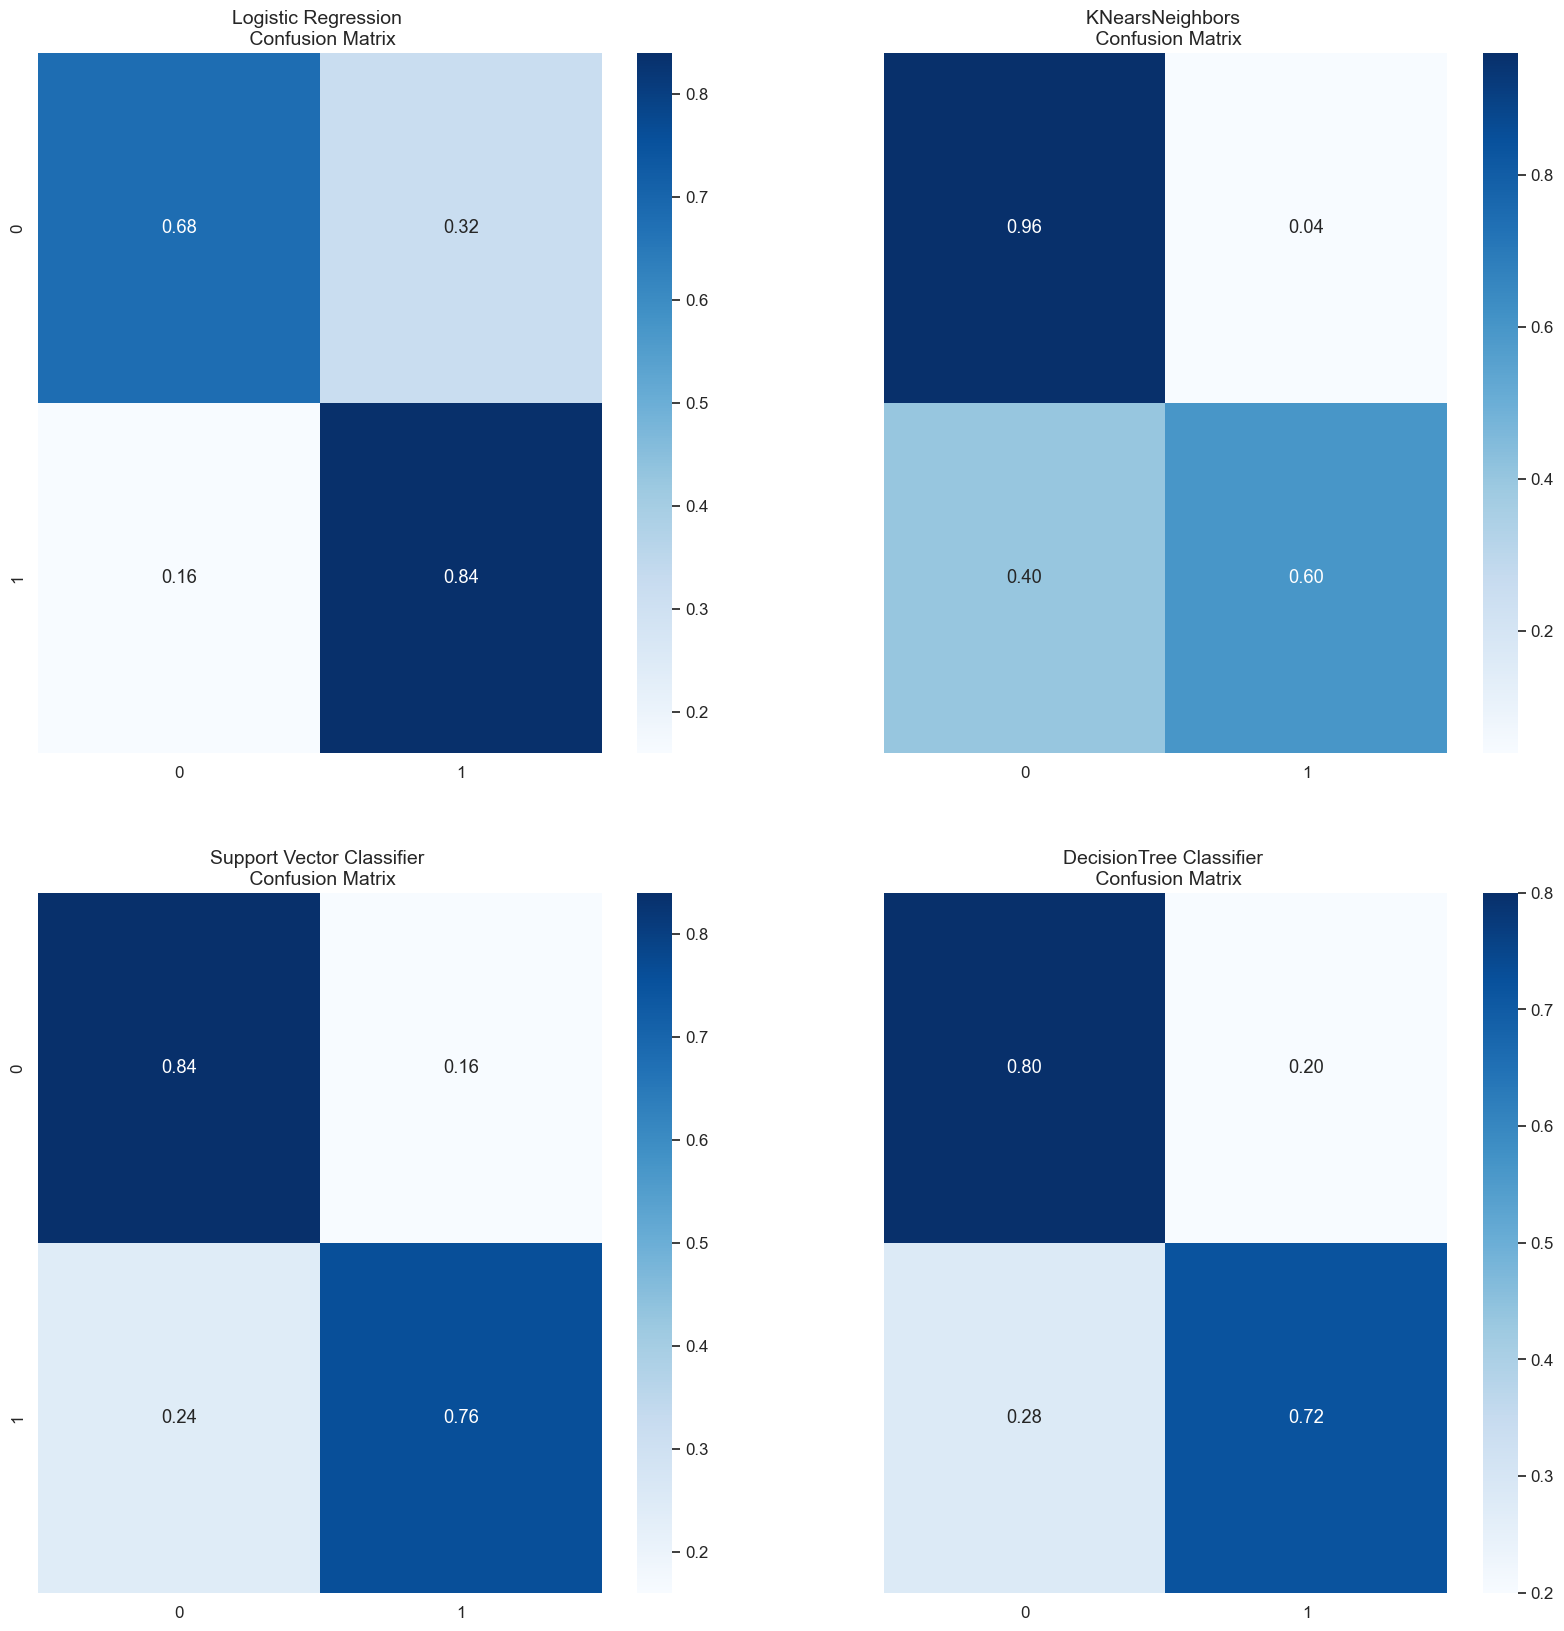

In [ ]:
y_pred_log_reg = best_est.predict(X_test)
y_pred_knear = knears_neighbors.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)

log_reg_cf = confusion_matrix(y_test, y_pred_log_reg, normalize="true")
kneighbors_cf = confusion_matrix(y_test, y_pred_knear, normalize="true")
svc_cf = confusion_matrix(y_test, y_pred_svc, normalize="true")
tree_cf = confusion_matrix(y_test, y_pred_tree, normalize="true")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20), sharey=True)

sns.heatmap(ax=ax1, data=log_reg_cf, annot=True, fmt=".2f", cmap="Blues")
ax1.set_title("Logistic Regression \n Confusion Matrix", fontsize=14)

sns.heatmap(ax=ax2, data=kneighbors_cf, annot=True, fmt=".2f", cmap="Blues")
ax2.set_title("KNearsNeighbors \n Confusion Matrix", fontsize=14)

sns.heatmap(ax=ax3, data=svc_cf, annot=True, fmt=".2f", cmap="Blues")
ax3.set_title("Support Vector Classifier \n Confusion Matrix", fontsize=14)

sns.heatmap(ax=ax4, data=tree_cf, annot=True, fmt=".2f", cmap="Blues")
ax4.set_title("DecisionTree Classifier \n Confusion Matrix", fontsize=14)

plt.show()


На balanced hold-out подвыборке матрицы ошибок показывают, что модели уже неплохо различают классы.
Но для честного сравнения SMOTE и baseline стоит посмотреть еще и на full-data fold.


In [ ]:
baseline_log_reg_full = clone(log_reg).fit(fold_Xtrain, fold_ytrain)
baseline_knear_full = clone(knears_neighbors).fit(fold_Xtrain, fold_ytrain)
baseline_svc_full = clone(svc).fit(fold_Xtrain, fold_ytrain)
baseline_tree_full = clone(tree_clf).fit(fold_Xtrain, fold_ytrain)

print("Logistic Regression:")
print(classification_report(fold_ytest, best_est.predict(fold_Xtest), target_names=LABELS))

print("KNears Neighbors:")
print(classification_report(fold_ytest, baseline_knear_full.predict(fold_Xtest), target_names=LABELS))

print("Support Vector Classifier:")
print(classification_report(fold_ytest, baseline_svc_full.predict(fold_Xtest), target_names=LABELS))

print("Decision Tree Classifier:")
print(classification_report(fold_ytest, baseline_tree_full.predict(fold_Xtest), target_names=LABELS))


Logistic Regression:
              precision    recall  f1-score   support

  Status 0/1       0.87      0.68      0.76        38
    Status 2       0.64      0.84      0.72        25

    accuracy                           0.75        63
   macro avg       0.75      0.76      0.74        63
weighted avg       0.78      0.75      0.75        63

KNears Neighbors:
              precision    recall  f1-score   support

  Status 0/1       0.75      0.87      0.80        38
    Status 2       0.74      0.56      0.64        25

    accuracy                           0.75        63
   macro avg       0.74      0.71      0.72        63
weighted avg       0.74      0.75      0.74        63

Support Vector Classifier:
              precision    recall  f1-score   support

  Status 0/1       0.74      0.76      0.75        38
    Status 2       0.62      0.60      0.61        25

    accuracy                           0.70        63
   macro avg       0.68      0.68      0.68        63
weighted

Поскольку в блокноте-примере финально сравниваются under-sampling и over-sampling,
здесь тоже сведем итог в компактную таблицу.


In [ ]:
undersample_score = accuracy_score(fold_ytest, baseline_log_reg_full.predict(fold_Xtest))
oversample_score = accuracy_score(fold_ytest, best_est.predict(fold_Xtest))

final_df = pd.DataFrame(
    {
        "Метод": ["Baseline Logistic Regression", "Oversampling (SMOTE)"],
        "Score": [undersample_score, oversample_score],
    }
)

final_df


,Метод,Score
0,Baseline Logistic Regression,0.746032
1,Oversampling (SMOTE),0.746032
